**Problem Set 2 Relatividad y Gravitación Parte númerica y Gráfica (Geodésicas)**

**Fecha:** 08 de Junio de 2025

**Estudiante:** Bryan Camilo Restrepo Arcila

Instalación de las librerias

In [60]:
!pip install -q sympy numpy matplotlib einsteinpy scipy

Importación de las librerias

In [61]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import einsteinpy.symbolic as es
from einsteinpy.symbolic.metric import MetricTensor
from einsteinpy.symbolic.christoffel import ChristoffelSymbols
from scipy.integrate import odeint
from IPython.display import display, Math

## TEM. **Transformación general del tensor de Faraday [Numérico]**

Usar herramientas de cálculo simbólico (`sympy`o `einsteinpy`) para encontrar la forma general, es decir, cuándo la velocidad $\vec u_L$ no esta en la configuración estándar, en la que transforman los campos eléctrico y magnético, y demostrar que son equivalentes a las expresiones vectoriales:

  \begin{aligned}
  & \vec{E}=\vec{E}^{\prime}+(\gamma-1) \vec{E}_{\perp}^{\prime}-\gamma \vec{u}_L \times \vec{B}’ \\
  
  & \vec{B}=\vec{B}^{\prime}+(\gamma-1) \vec{B}_{\perp}^{\prime}+\gamma \vec{u}_L \times \vec{E}^{\prime}
  \end{aligned}

In [62]:
# Símbolos y vectores relevantes
u_x, u_y, u_z = sp.symbols('u_x u_y u_z', real=True)
Epx, Epy, Epz = sp.symbols('Epx Epy Epz', real=True)
Bpx, Bpy, Bpz = sp.symbols('Bpx Bpy Bpz', real=True)

u_vec = sp.Matrix([u_x, u_y, u_z])
E_prime = sp.Matrix([Epx, Epy, Epz])
B_prime = sp.Matrix([Bpx, Bpy, Bpz])
u_sq = u_vec.dot(u_vec)
gamma = sp.simplify(1 / sp.sqrt(1 - u_sq))
gamma_minus_one = gamma - 1

# Matriz de Lorentz general 
Lambda = sp.eye(4)
Lambda[0, 0] = gamma
Lambda[0, 1:] = (-gamma * u_vec).T
Lambda[1:, 0] = -gamma * u_vec
Lambda[1:, 1:] = sp.eye(3) + (gamma_minus_one / u_sq) * (u_vec * u_vec.T)

# Tensor F′ en el sistema primado
F_prime = sp.Matrix([[0,     Epx,     Epy,     Epz],
                     [-Epx,    0,   -Bpz,     Bpy],
                     [-Epy,  Bpz,      0,    -Bpx],
                     [-Epz, -Bpy,    Bpx,       0]])

# Campos en sistema no primado
F = sp.simplify(Lambda * F_prime * Lambda.T)
E_vec = sp.Matrix([F[0, 1], F[0, 2], F[0, 3]])
B_vec = sp.Matrix([
    -sp.Rational(1, 2) * sum(sp.LeviCivita(i, j, k) * F[j + 1, k + 1]
                             for j in range(3) for k in range(3))
    for i in range(3)
])

# Expresiones vectoriales esperadas 
E_para = (E_prime.dot(u_vec) / u_sq) * u_vec
E_perp = E_prime - E_para
B_para = (B_prime.dot(u_vec) / u_sq) * u_vec
B_perp = B_prime - B_para

cross_u_B = u_vec.cross(B_prime)
cross_u_E = u_vec.cross(E_prime)

E_rhs = sp.simplify(E_prime + gamma_minus_one * E_perp - gamma * cross_u_B)
B_rhs = sp.simplify(B_prime + gamma_minus_one * B_perp + gamma * cross_u_E)

# Verificación: E_check = E - E_rhs ; B_check = B - B_rhs
E_check = sp.simplify(E_vec - E_rhs)
B_check = sp.simplify(B_vec - B_rhs)

# Mostrando los resultados
display(Math(r'\vec{E}_{\text{transformada}} = ' + sp.latex(sp.simplify(E_vec))))
display(Math(r'\vec{E}_{\text{esperada}} = ' + sp.latex(E_rhs)))
display(Math(r'\vec{E}_{\text{check}} = ' + sp.latex(E_check)))

display(Math(r'\vec{B}_{\text{transformada}} = ' + sp.latex(B_vec)))
display(Math(r'\vec{B}_{\text{esperada}} = ' + sp.latex(B_rhs)))
display(Math(r'\vec{B}_{\text{check}} = ' + sp.latex(B_check)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

En el anterior codigo se hizo la transformación de los campos de manera generalizada,  y además se obtuvo la version expandida de la versión esperada. permitiendo hacer una resta vectorial entre ambas expresiones, obteniendo para ambos campos $\vec{B}$ y $\vec{E}$ el vector $\vec{0}$, esto implica que ambas expresiones son equivalentes.

---

## TED. **Tensor electromagnético dual [Numérico]**.

Una cantidad de mucha utilidad en la electrodinámica es el tensor electromagnético dual, que se define como:

  $$
  {}^{*}F^{\mu\nu} = \frac{1}{2}\epsilon^{\mu\nu\alpha\beta}F_{\alpha\beta}
  $$

1. Encontrar, usando `sympy` o `einsteinpy`, las componentes explícitas del dual contravariante ${}^{*}F^{\mu\nu}$ y el dual covariante ${}^{*}F_{\mu\nu}$

  **Ayuda**: Hay distintas maneras de hacerlo. Puede usar la rutina `sympy.LeviCivita` que permite calcular las componentes del tensor de Levi-Civita de cualquier dimensión.

2. Usando el dual mostrar, usando `sympy` o `einsteinpy` que:

  $$
  (\vec E\cdot\vec B) = \frac{1}{4}{}^{*}F^{\mu\nu}F_{\mu\nu}
  $$

In [63]:
# Símbolos para los campos
Ex, Ey, Ez, Bx, By, Bz = sp.symbols('Ex Ey Ez Bx By Bz')

# Métrica de Minkowski
g = sp.diag(1, -1, -1, -1)
g_inv = g.inv()

# Tensor F_{mu,nu}
F = sp.Matrix([
    [0,   -Ex, -Ey, -Ez],
    [Ex,   0,  -Bz,  By],
    [Ey,  Bz,   0,  -Bx],
    [Ez, -By,  Bx,   0],
])

# Subir índices: F^{mu,nu} = g^{mu,alpha} g^{nu,beta} F_{alpha,beta}
F_up = g_inv * F * g_inv

# Construir el dual: *F^{mu,nu} = 1/2 epsilon^{mu nu alpha beta} F_{alpha beta}
epsilon = sp.LeviCivita
F_star_up = sp.zeros(4, 4)
for mu in range(4):
    for nu in range(4):
        F_star_up[mu, nu] = sp.simplify(
            sp.Rational(1, 2) *
            sum(epsilon(mu, nu, a, b) * F[a, b]
                for a in range(4) for b in range(4))
        )

# Bajar índices: *F_{mu,nu} = g_{mu,alpha} g_{nu,beta} *F^{alpha beta}
F_star_down = g * F_star_up * g

# Identidad
contract = sum(F_star_up[mu, nu] * F[mu, nu]
               for mu in range(4) for nu in range(4))
contract_simpl = sp.simplify(contract)

# E·B
E_dot_B = Ex*Bx + Ey*By + Ez*Bz

# Mostrar resultados
display(Math(r"*F^{\mu \nu} = " + sp.latex(F_star_up)))
display(Math(r"*F_{\mu \nu} = " + sp.latex(F_star_down)))
display(Math(r"\frac{1}{4} *F^{\mu \nu} F_{\mu \nu} = " + sp.latex(contract_simpl/4)))
display(Math(r"\vec{E} \cdot \vec{B} = " + sp.latex(E_dot_B)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Teniendo en cuenta las ultimas dos expresiones es claro que:
 $$
  (\vec E\cdot\vec B) = \frac{1}{4}{}^{*}F^{\mu\nu}F_{\mu\nu}
  $$

---

## GE. **Geodésicas en un espacio cerrado**.

Un espacio de dos dimensiones tiene métrica:

$$
\mathrm{d}s^2 = \sin^2(y/R)\;\mathrm{d}x^2 + \mathrm{d}y^2
$$
donde $R$ es un parámetro libre.

1. Verifique numéricamente la expresión analítica de los símbolos de Christoffel de esta métrica.

3. Resuelva numéricamente las ecuaciones de las geodésicas usando condiciones iniciales apropiadas y haga gráficos de las geodésicas. ¿Qué observa?

4. Repita el dibujo de las geodésicas, interpretando el resultado como si fuera la superficie de la Tierra y comente sus resultados.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

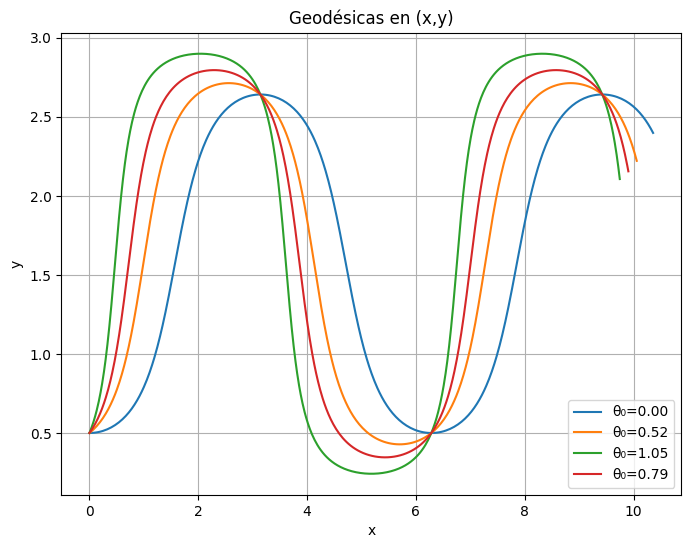

In [64]:
# Definición de símbolos y la métrica
x, y, R = sp.symbols('x y R')
coords = (x, y)
g_matrix = [[sp.sin(y/R)**2, 0],
            [0,               1]]
metric = es.MetricTensor(g_matrix, coords, name="2D_Metric")

# Cálculo de los símbolos de Christoffel
G = es.ChristoffelSymbols.from_metric(metric)
Gamma_raw = G.tensor()  
Gamma = [[[sp.simplify(Gamma_raw[k][i][j])
           for j in range(2)] for i in range(2)] for k in range(2)]

# Mostrar sólo los no nulos
display(Math(r"\text{Símbolos de Christoffel no nulos:}"))
for k in range(2):
    for i in range(2):
        for j in range(2):
            if Gamma[k][i][j] != 0:
                display(Math(
                    rf"\Gamma^{{{coords[k]}}}_{{{coords[i]}{coords[j]}}}"
                    rf" = {sp.latex(Gamma[k][i][j])}"
                ))

# Preparando para la integración numérica
Gamma_funcs = [[[sp.lambdify((y, R), Gamma[k][i][j], 'numpy')
                 for j in range(2)] for i in range(2)] for k in range(2)]

# Ecuaciones de geodésica
def geodesic_ode(state, t, R_val):
    x_val, y_val, vx, vy = state
    ax = -sum(
        Gamma_funcs[0][i][j](y_val, R_val) * state[2+i] * state[2+j]
        for i in range(2) for j in range(2)
    )
    ay = -sum(
        Gamma_funcs[1][i][j](y_val, R_val) * state[2+i] * state[2+j]
        for i in range(2) for j in range(2)
    )
    return [vx, vy, ax, ay]

# Graficar geodésicas
def plot_geodesics(R_val=1.0, y0=0.5, initial_angles=(0, np.pi/6, np.pi/3, np.pi/4)):
    t_eval = np.linspace(0, 10, 500)
    plt.figure(figsize=(8, 6))
    for angle in initial_angles:
        vx0 = np.cos(angle) / np.sin(y0 / R_val)
        vy0 = np.sin(angle)
        sol = odeint(geodesic_ode, [0, y0, vx0, vy0], t_eval, args=(R_val,))
        plt.plot(sol[:, 0], sol[:, 1], label=f"θ₀={angle:.2f}")
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Geodésicas en (x,y)')
    plt.legend()
    plt.grid(True)
    plt.show()


plot_geodesics(R_val=1.0)

Los simbolos de Christofel calculados fueron exactamente los mismos encontrados de manera manual.

En relación a la solución observada en la gráfica podemos decir las siguientes cosas:

- Para todos los $\theta$ hay puntos extremos máximos y minimos. Generando un patron oscilatorio típico de una función seno o coseno. esto implica que $\dot{y}$  varia entre positivo y negativo 

- Sin importar el valor de $\theta$ hay puntos donde todas las soluciones son númericamente iguales en (x, y). Estos indica que el periodo de la solución es independiente del $\theta$  en cuestión.

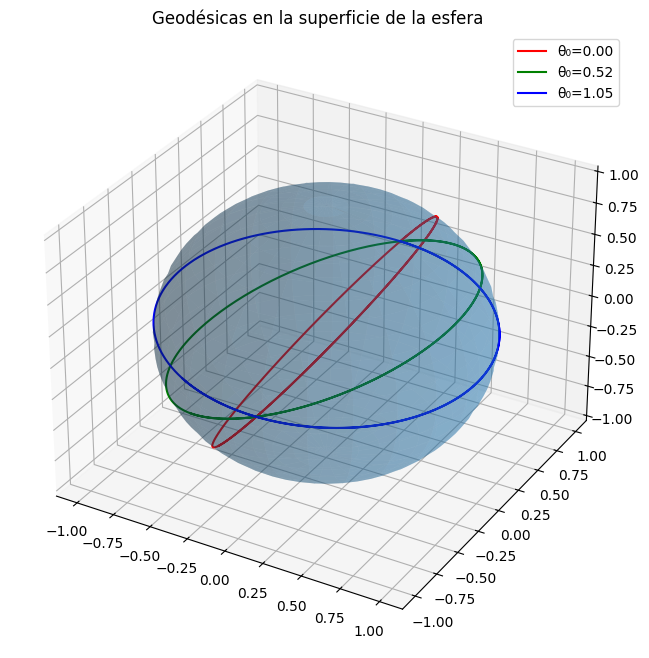

In [65]:
# Repetir integración de geodésicas
Gamma_funcs = [
    [
        [sp.lambdify((y, R), Gamma[k][i][j], 'numpy') for j in range(2)]
        for i in range(2)
    ]
    for k in range(2)
]

def geodesic_ode(state, t, R_val):
    x_val, y_val, vx, vy = state
    ax = -sum(Gamma_funcs[0][i][j](y_val, R_val) * state[2+i] * state[2+j]
              for i in range(2) for j in range(2))
    ay = -sum(Gamma_funcs[1][i][j](y_val, R_val) * state[2+i] * state[2+j]
              for i in range(2) for j in range(2))
    return [vx, vy, ax, ay]

# Condiciones y parámetros
R_val = 1.0
y0 = 0.5  # initial theta*R
initial_angles = [0, np.pi/6, np.pi/3]
t_eval = np.linspace(0, 10, 500)

# Preparar esfera
phi_grid = np.linspace(0, 2*np.pi, 50)
theta_grid = np.linspace(0, np.pi, 50)
Phi, Theta = np.meshgrid(phi_grid, theta_grid)
X_s = R_val * np.sin(Theta) * np.cos(Phi)
Y_s = R_val * np.sin(Theta) * np.sin(Phi)
Z_s = R_val * np.cos(Theta)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X_s, Y_s, Z_s, rstride=2, cstride=2, alpha=0.3)

colors = ['r', 'g', 'b']
for angle, c in zip(initial_angles, colors):
    vx0 = np.cos(angle) / np.sin(y0/R_val)
    vy0 = np.sin(angle)
    sol = odeint(geodesic_ode, [0, y0, vx0, vy0], t_eval, args=(R_val,))
    # Convertir solución a coordenadas
    phi_sol = sol[:, 0] / R_val
    theta_sol = sol[:, 1] / R_val
    # Coordenadas cartesianas
    Xg = R_val * np.sin(theta_sol) * np.cos(phi_sol)
    Yg = R_val * np.sin(theta_sol) * np.sin(phi_sol)
    Zg = R_val * np.cos(theta_sol)
    ax.plot(Xg, Yg, Zg, c, label=f'θ₀={angle:.2f}')

ax.set_title('Geodésicas en la superficie de la esfera')
ax.legend()
plt.show()

Si identificamos

$$
y = R\theta, \quad x = R\phi,
$$

Eso que antes eran oscilaciones en su interpretación x, y son  **Circulos Máximos** proyectados en la superficie de la esfera.  
En la Tierra real serían rutas de navegación que, vistas en una proyección $x$-$y$ , aparecen como ondulaciones pero en realidad son siempre la distancia más corta entre dos puntos en la superficie de la esfera. Lo que es muy útil por ejemplo para trazar grandes rutas de navegación.


---

## GN. **Geodésicas de la métrica de Newton**

La métrica de Newton, que permite reconstruir, por lo menos en situaciones de campos gravitacionales débiles, los efectos de la gravedad Newtoniana, se puede escribir como:

$$
\mathrm{d}s^2 = \left(1+\frac{2\phi}{c^2}\right)(c\mathrm{d}t)^2 - \mathrm{d}l^2
$$
donde $dl$ es la métrica de la hipersuperficie espacialoide $t=\mathrm{cte}$ (métrica euclidiana) y $\phi$ es el potencial gravitacional.

1. La situación más simple que podemos considerar es la de un campo gravitacional uniforme $\vec g = -g_0\hat{e_y}$. verifique numéricamente la expresión analítica de los símbolos de Christoffel 

In [66]:
# Coordenadas y símbolos
t, y, c, g0 = sp.symbols("t y c g0")
coords = (t, y)

# Potencial newtoniano uniforme: Phi = g_0 * y
phi = g0 * y

# Métrica de Newton
g_adjusted = [
    [(1 + 2 * phi / c**2), 0],
    [0, -1]
]

# Tensor métrico
metric = MetricTensor(g_adjusted, coords, name="Newtonian")

# Calcular símbolos de Christoffel
Gamma = ChristoffelSymbols.from_metric(metric)
Gamma_tensor = Gamma.tensor()

# Mostrar los no nulos
display(Math(r"\text{Símbolos de Christoffel no nulos (forma sin } c^2\text{ frente a } dt^2\text{):}"))
for k in range(2):
    for i in range(2):
        for j in range(2):
            expr = sp.simplify(Gamma_tensor[k][i][j])
            if expr != 0:
                display(Math(
                    rf"\Gamma^{{{coords[k]}}}_{{{coords[i]}{coords[j]}}} = {sp.latex(expr)}"
                ))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Este es exactamente el resultado que se obtuvo de manera manual para los simbolos de Christoffel de la métrica de Newton.

Como Jercicio final vveamos los resultados de integración  de un movimiento de caida libre teniendo en cuenta  la geodésica que describe el movimeinto y la soluciónb clásica de Newton para este problema.

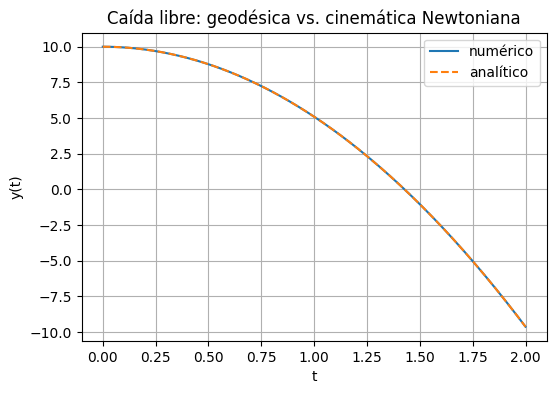

In [67]:
# Símbolos y coordenadas (t, y)
t, y, c, g0 = sp.symbols('t y c g0')
coords_uni = (t, y)

# Métrica Newtoniana aproximada en campo uniforme
phi_uni = g0 * y
g_uni = sp.diag((1 + 2*phi_uni/c**2) * c**2, -1)
g_uni_inv = g_uni.inv()

# Christoffel symbols
Gamma_uni = [[[sp.simplify( sp.Rational(1,2) * sum(
    g_uni_inv[k, l] * (sp.diff(g_uni[l, j], coords_uni[i])
                     + sp.diff(g_uni[l, i], coords_uni[j])
                     - sp.diff(g_uni[i, j], coords_uni[l]))
    for l in range(2)
)) for j in range(2)] for i in range(2)] for k in range(2)]

def geod_uniform(state, t, g0_val):
    y, vy = state
    ay = -float(Gamma_uni[1][0][0].subs({y:y, c:1, g0:g0_val}))
    return [vy, ay]

# Parámetros
g0_val = 9.81
y0, vy0 = 10.0, 0.0
t_span = (0, 2.0)
t_eval = np.linspace(*t_span, 200)

sol_uni = odeint(geod_uniform, [y0, vy0], t_eval, args=(g0_val,))
y_num = sol_uni[:, 0]
y_anal = y0 + vy0*t_eval - 0.5*g0_val*t_eval**2

plt.figure(figsize=(6,4))
plt.plot(t_eval, y_num, label="numérico")
plt.plot(t_eval, y_anal, "--", label="analítico")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.title("Caída libre: geodésica vs. cinemática Newtoniana")
plt.legend()
plt.grid(True)
plt.show()


---

**Referencias**

Para el desarrollo de algunas partes de este notebook, se utilizó ChatGPT, un modelo de lenguaje de OpenAI, como herramienta de asistencia. Las interacciones con ChatGPT ayudaron en la conceptualización, codificación y depuración de las secciones relevantes.